In [9]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [11]:
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


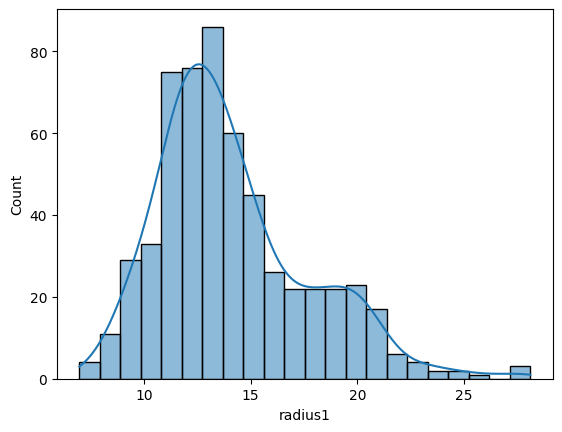

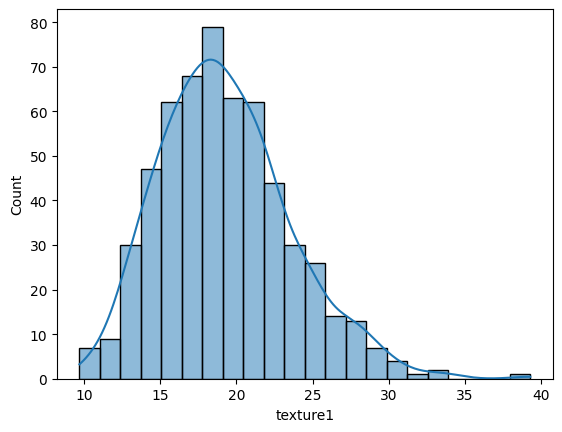

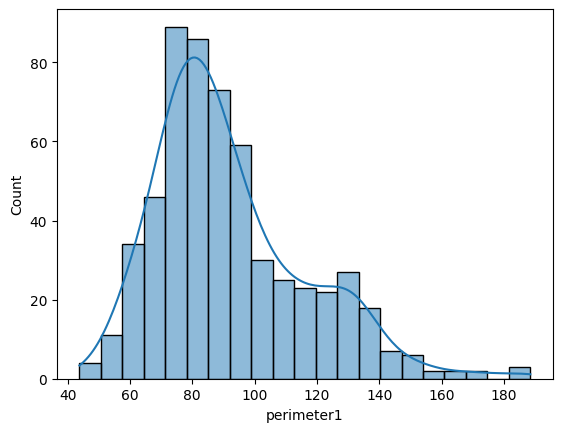

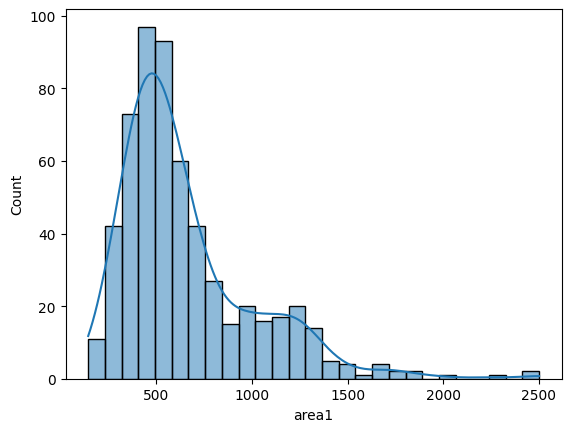

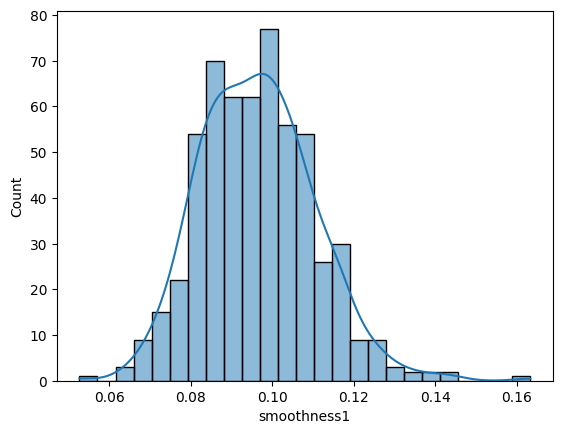

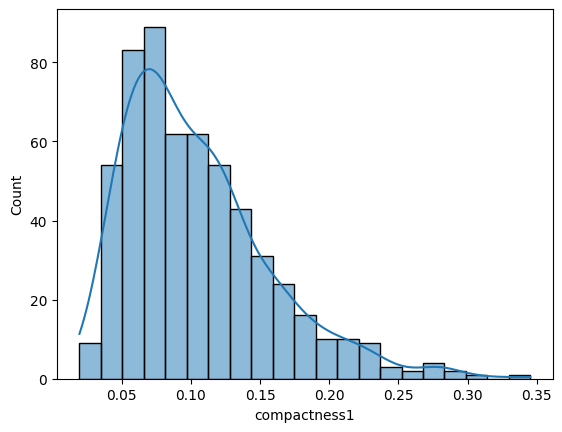

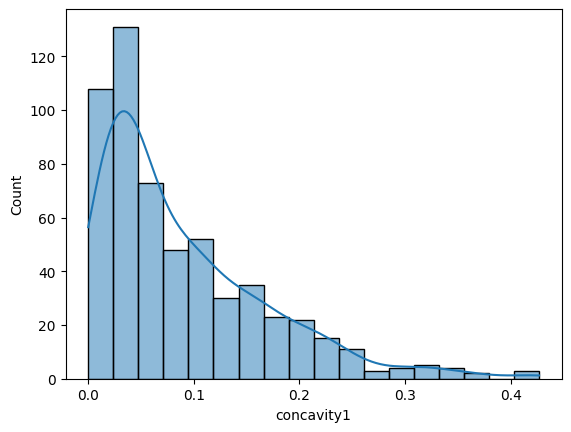

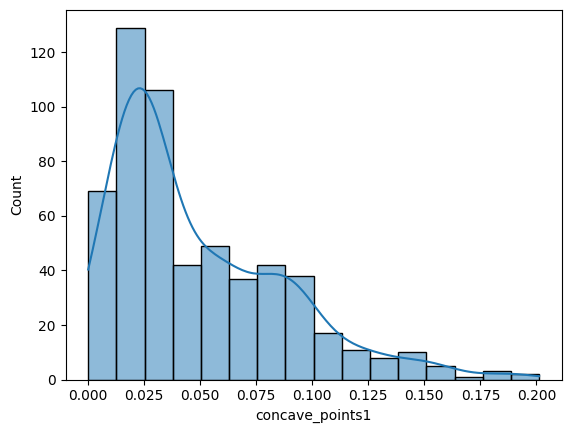

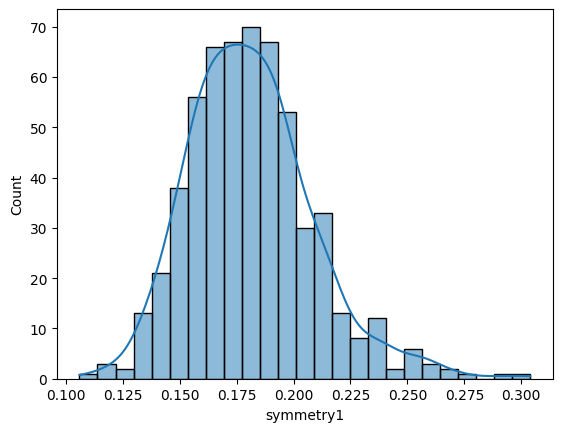

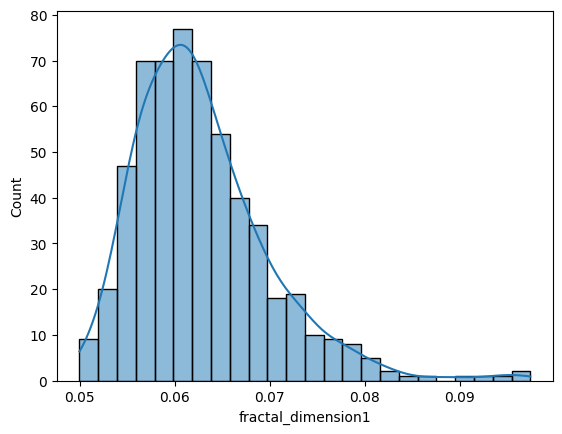

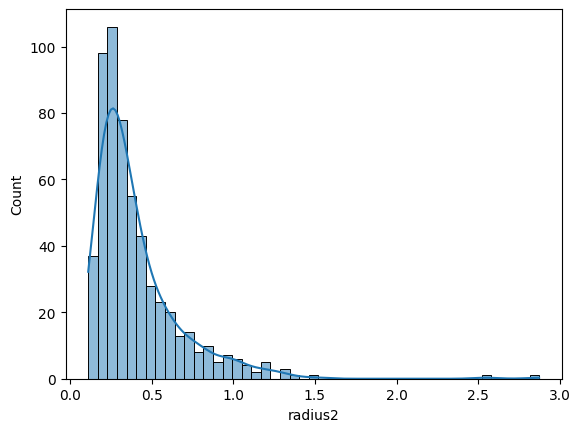

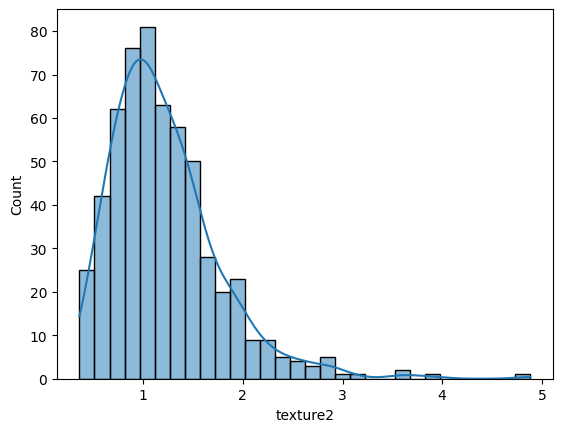

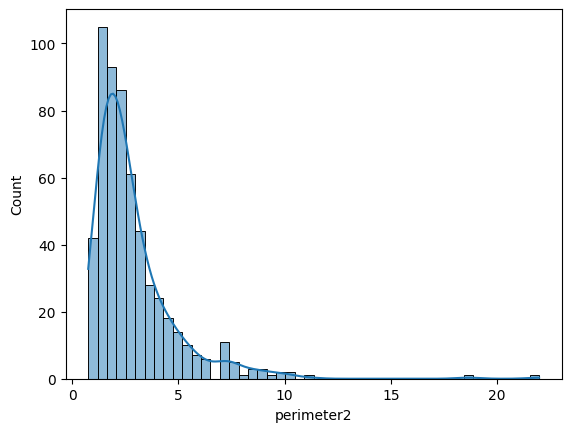

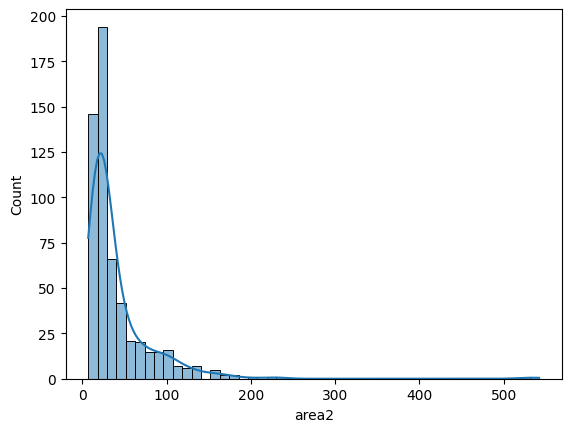

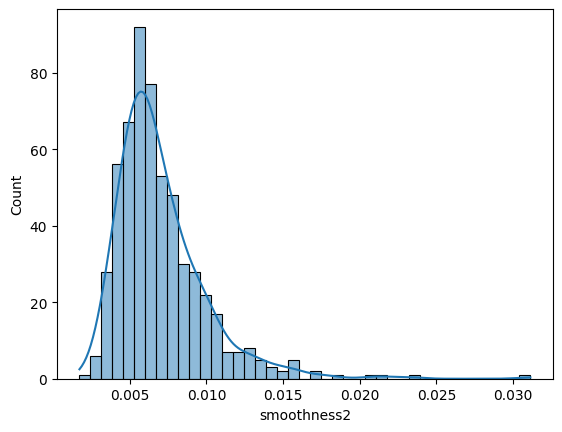

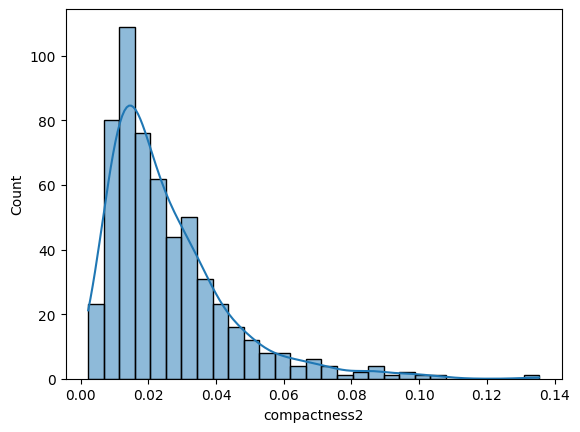

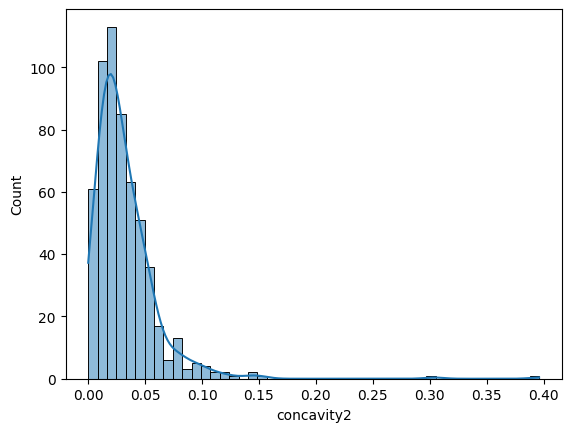

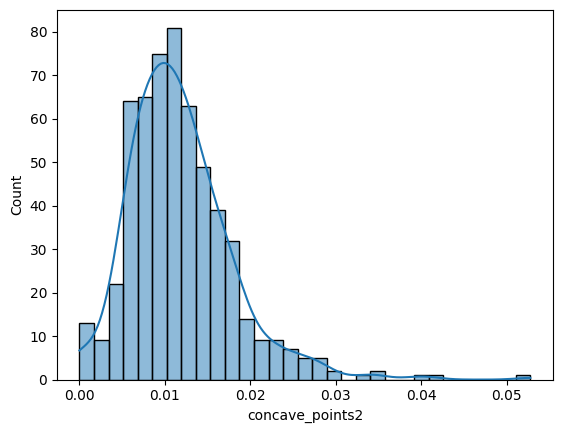

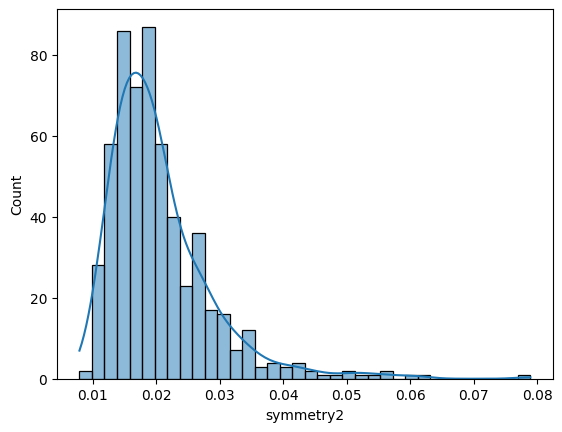

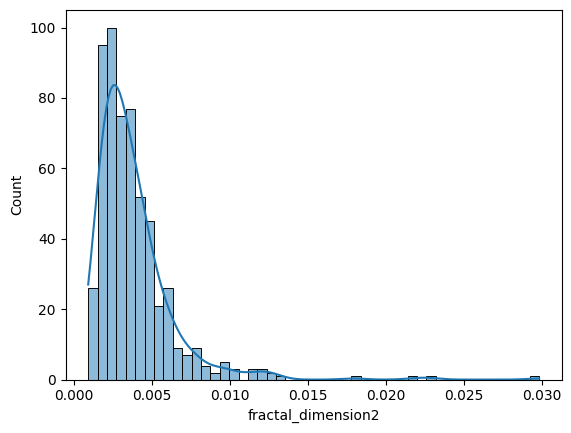

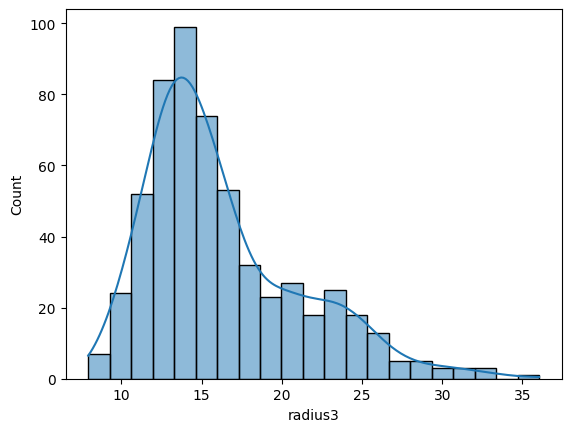

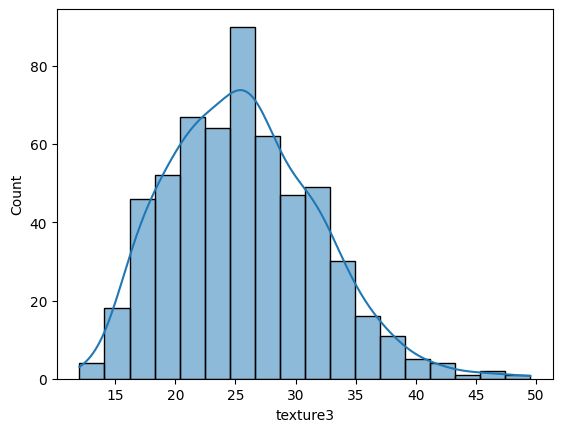

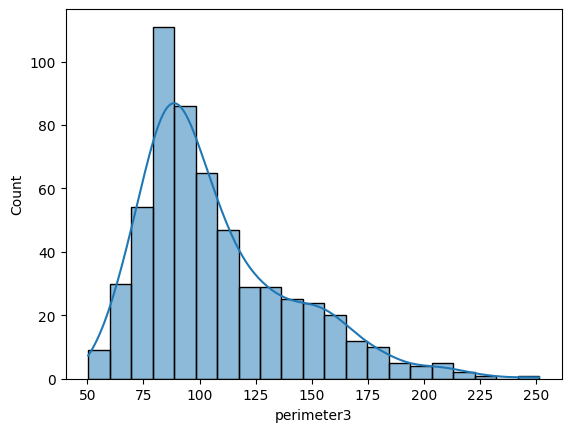

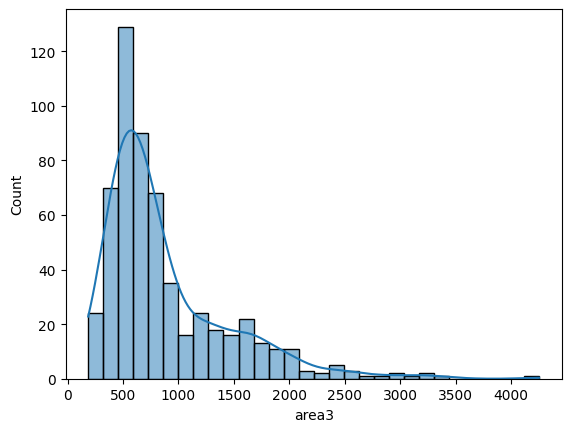

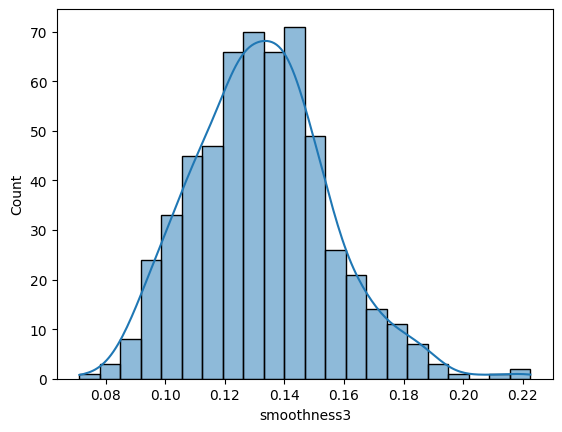

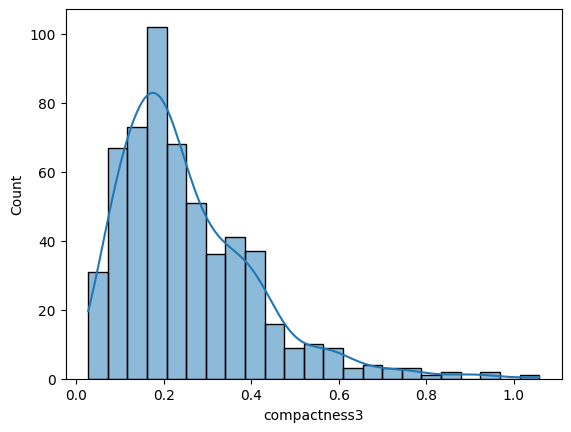

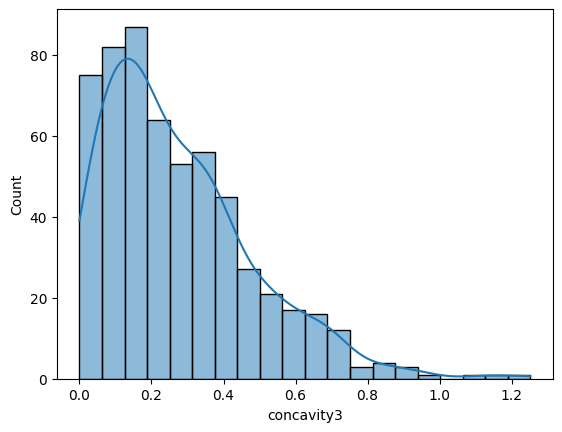

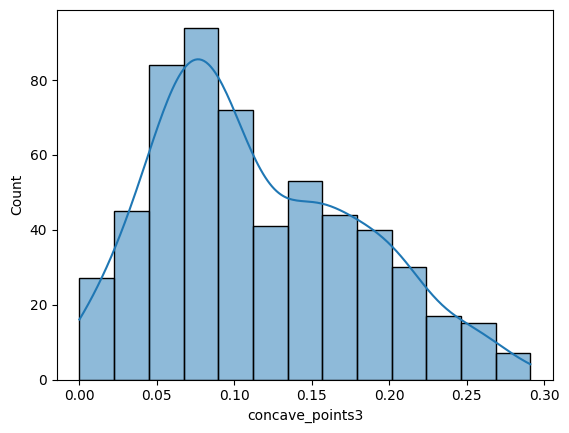

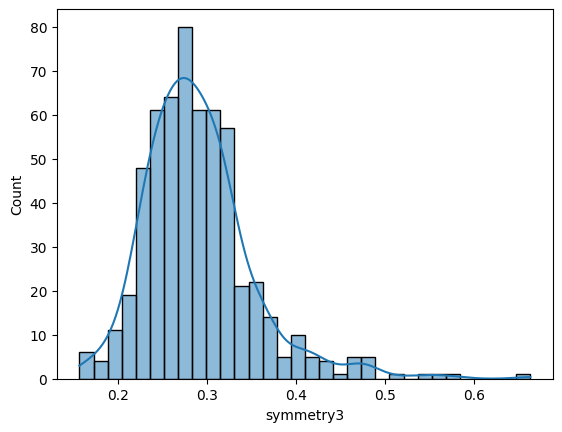

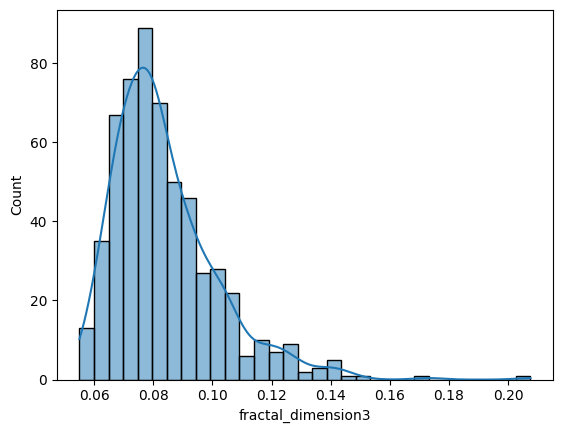

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = X.columns

for column in columns:
    sns.histplot(X[column], kde=True)
    plt.show()
    


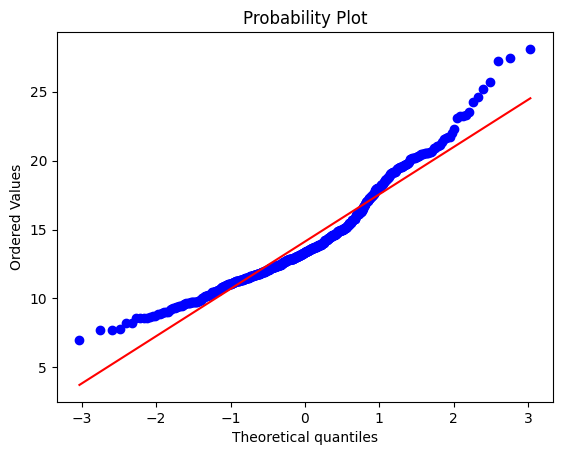

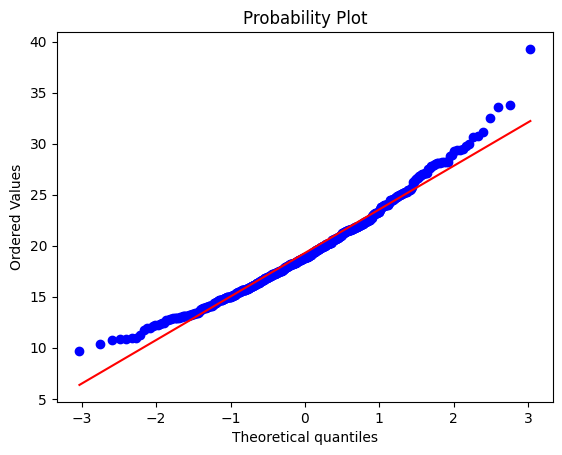

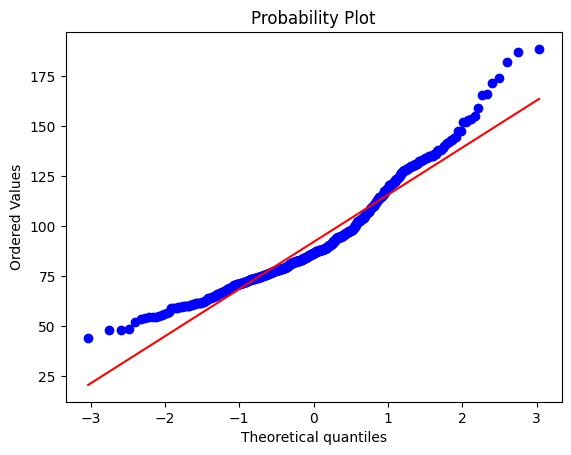

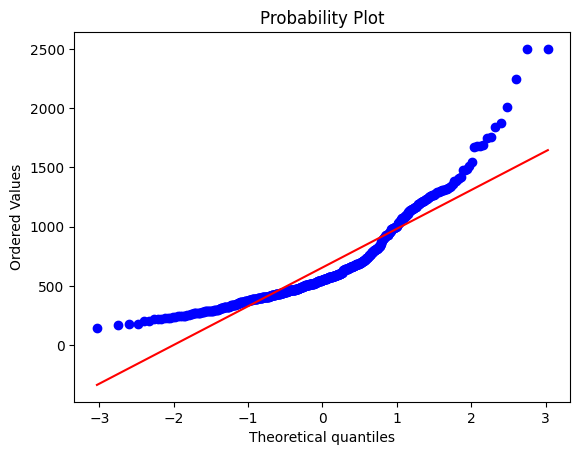

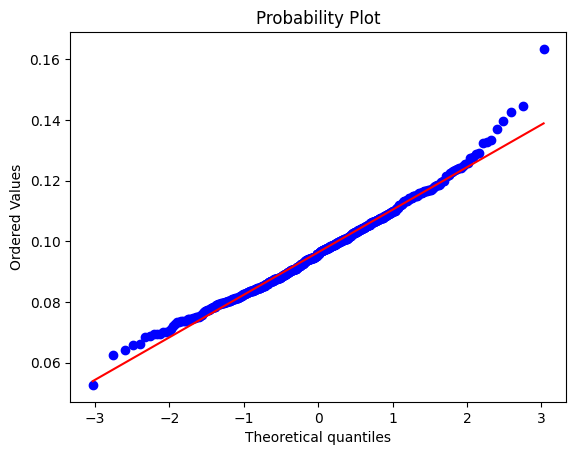

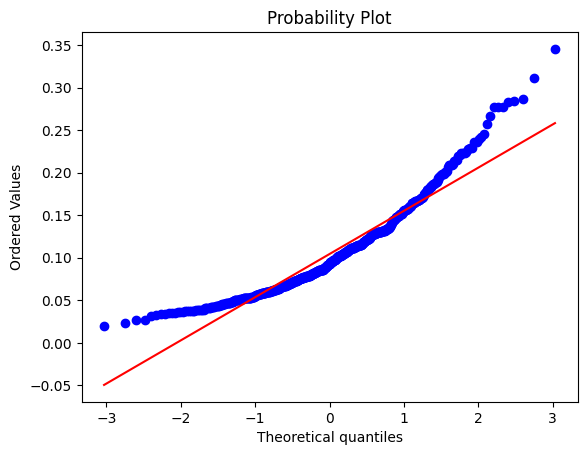

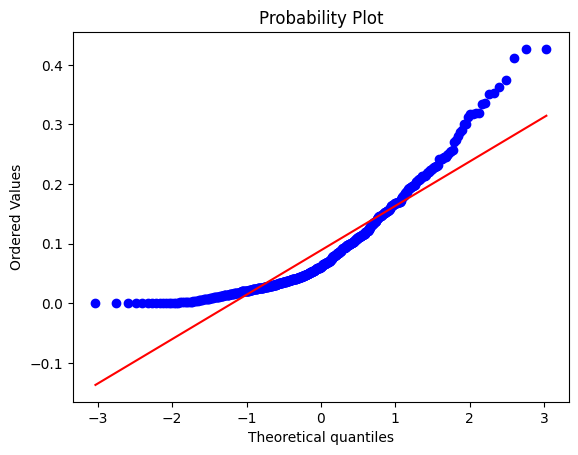

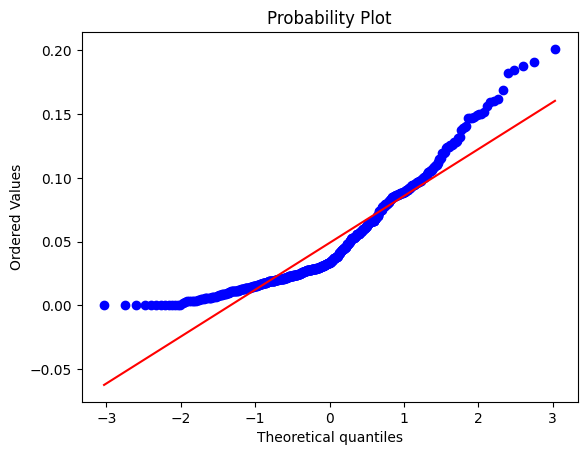

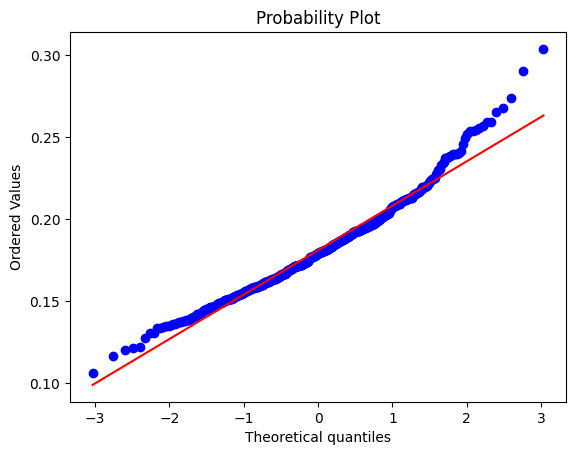

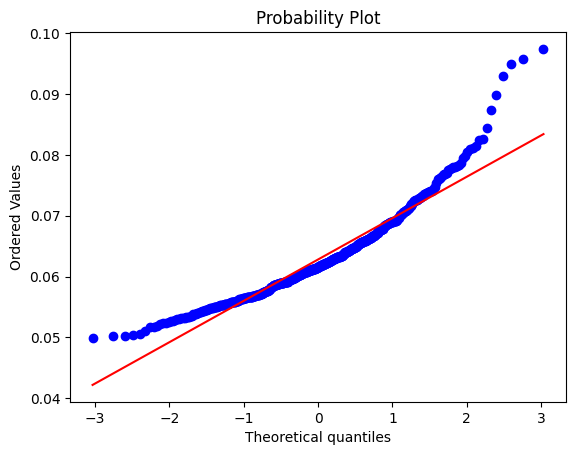

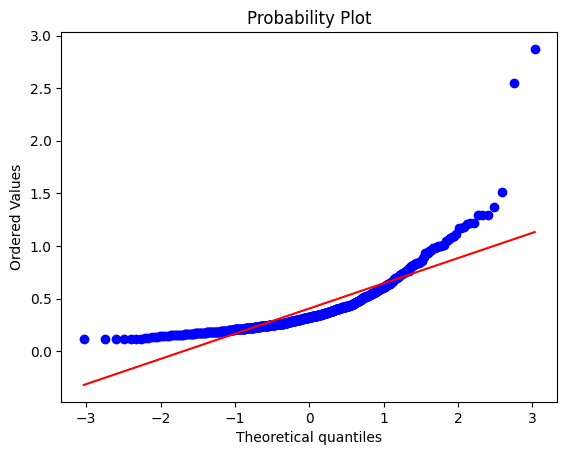

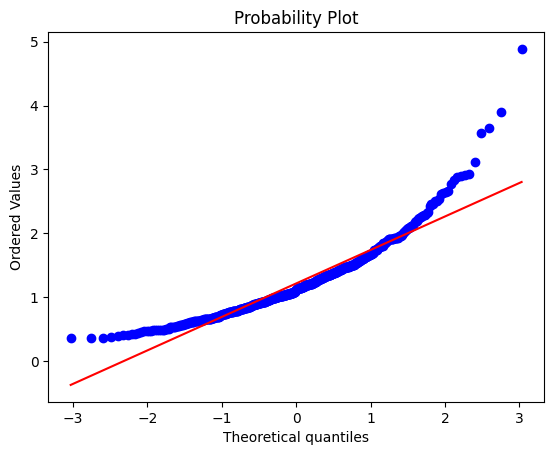

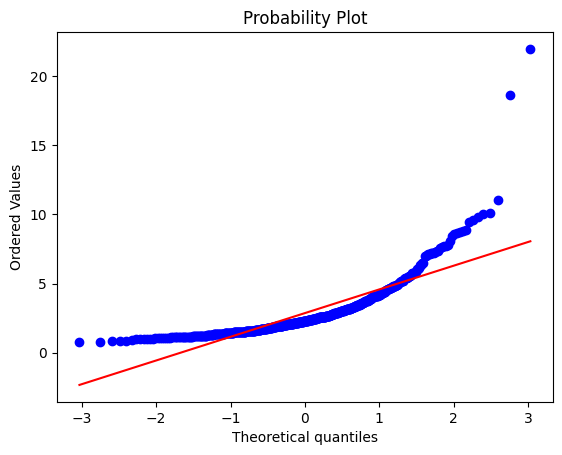

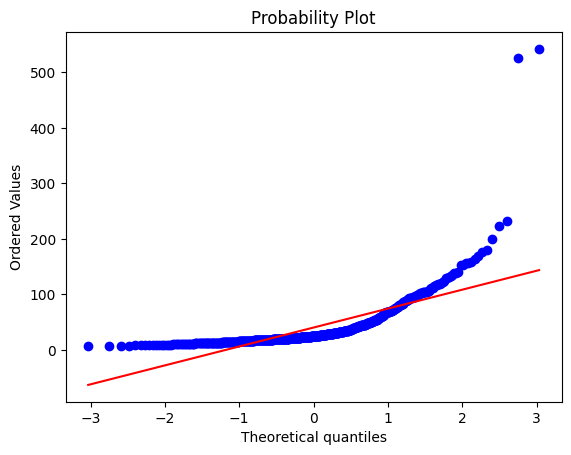

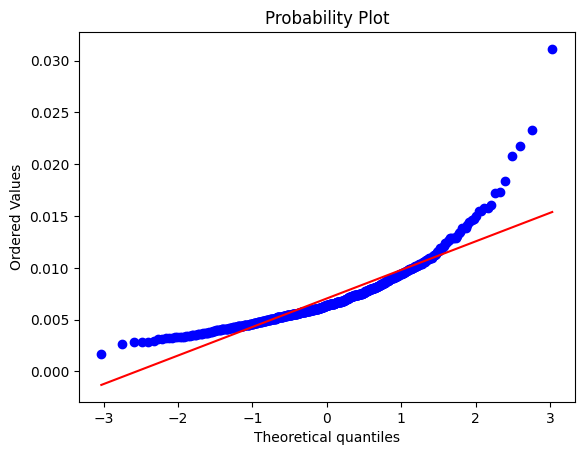

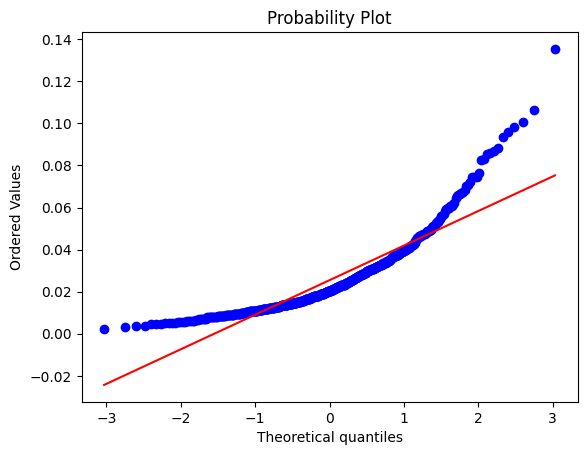

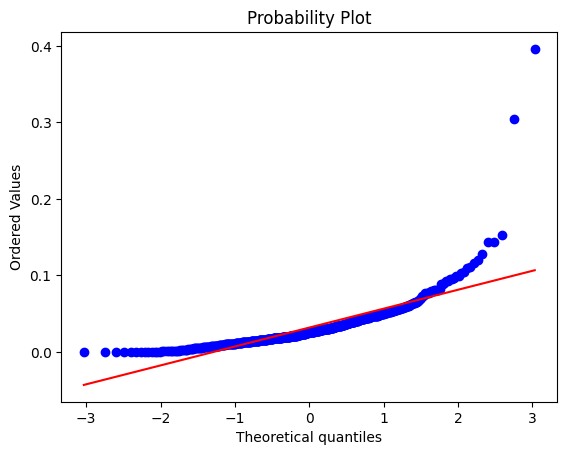

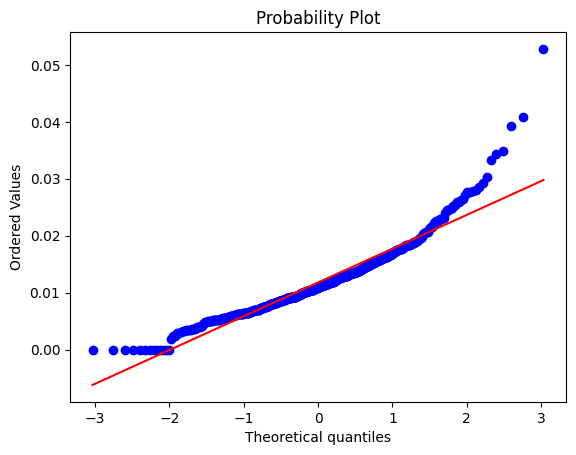

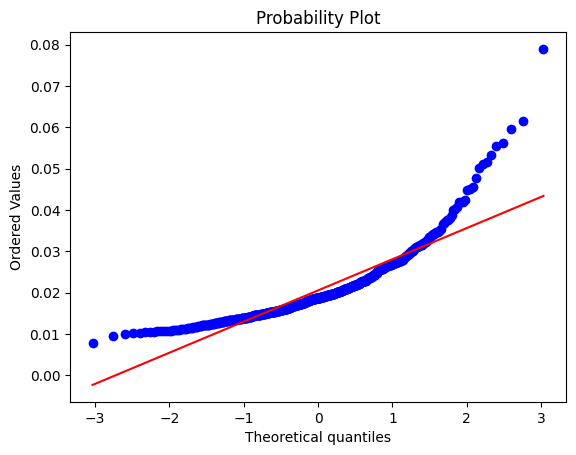

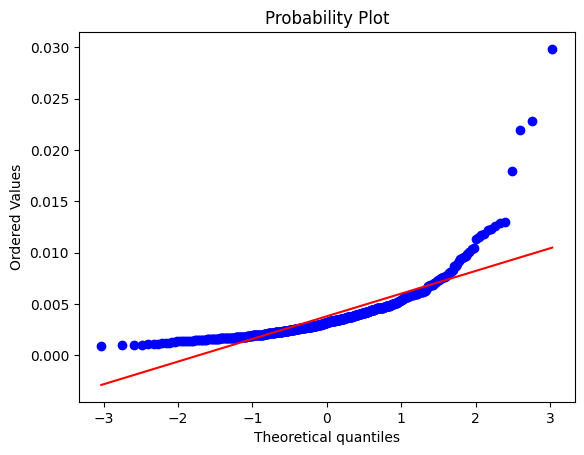

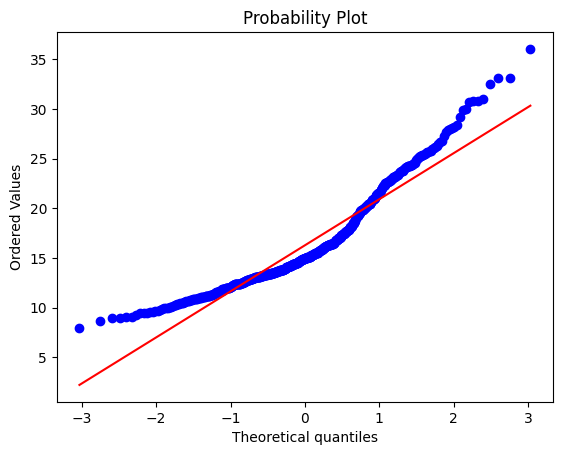

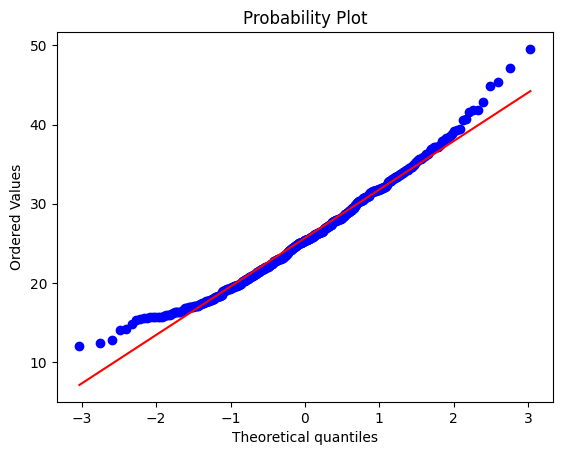

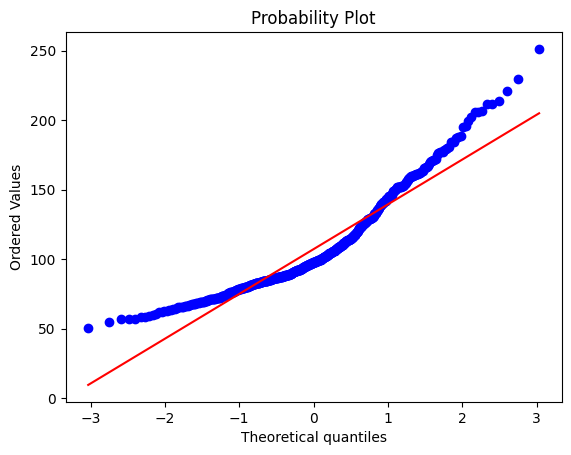

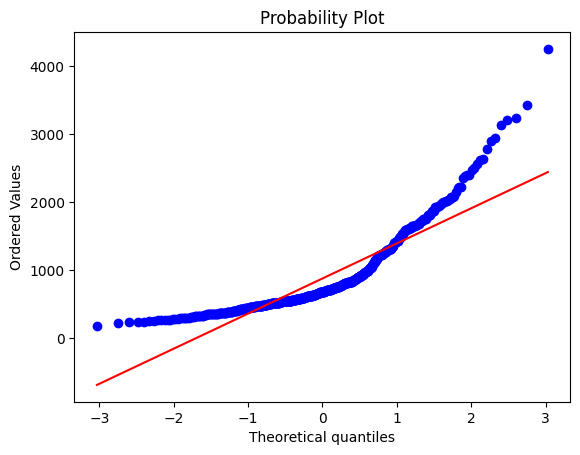

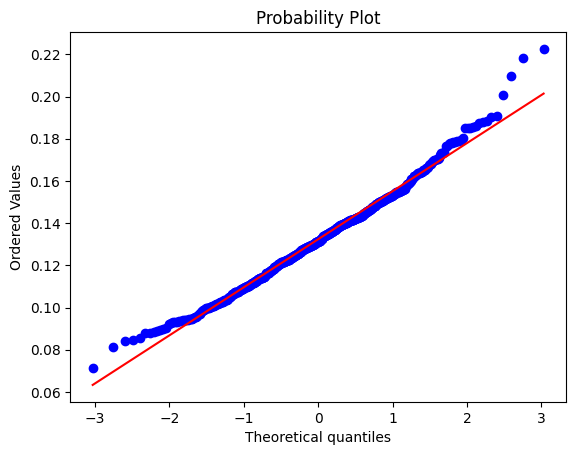

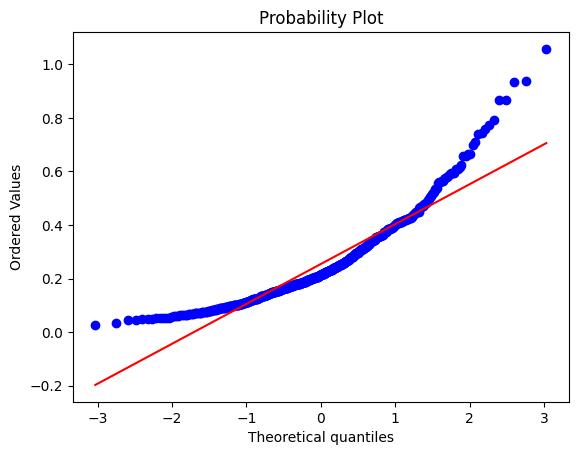

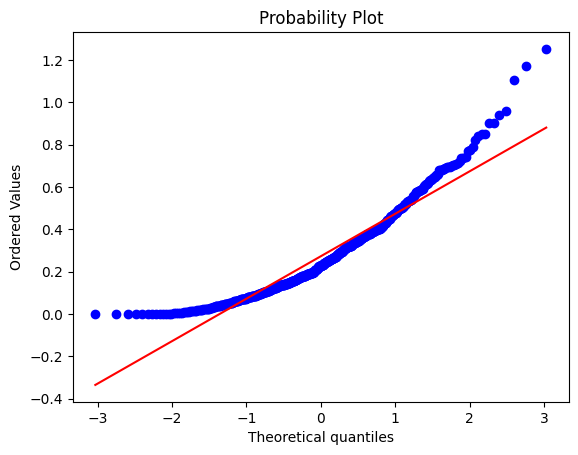

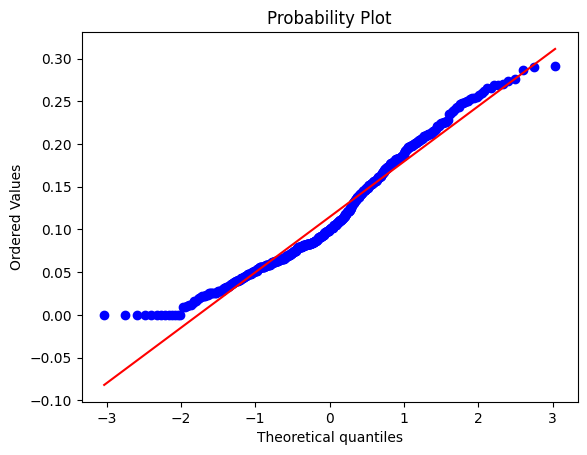

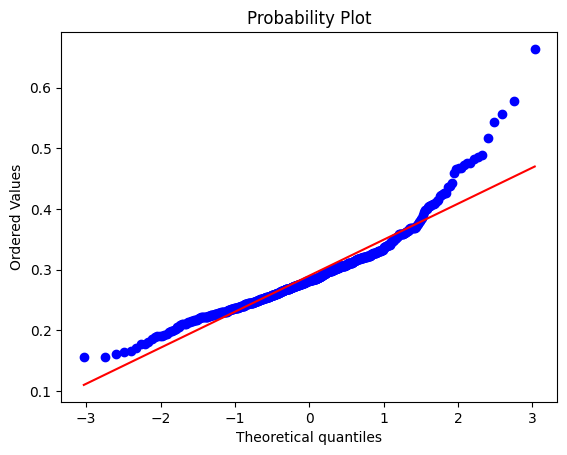

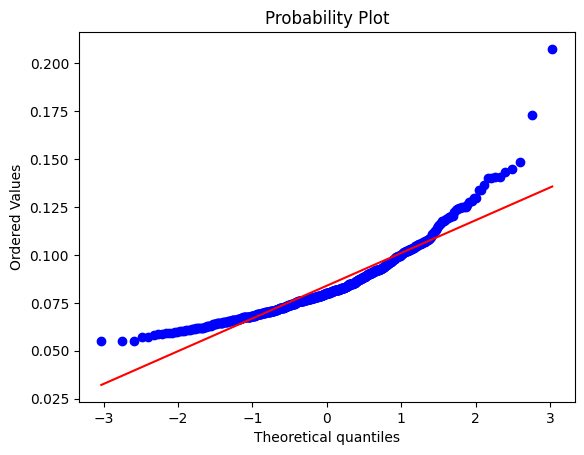

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt

for column in columns:
    stats.probplot(X[column], dist="norm", plot=plt)
    plt.show()

In [20]:
len(X)

569

In [68]:
from scipy.stats import shapiro

for column in columns:
    print('='*30)
    print(f'Columna {column}')
    stat, p = shapiro(X[column])
    print(f'Estadístico={stat:.3f}, p-value={p:.3f}')
    if p < 0.05: print('No Normal')

Columna radius1
Estadístico=0.941, p-value=0.000
No Normal
Columna texture1
Estadístico=0.977, p-value=0.000
No Normal
Columna perimeter1
Estadístico=0.936, p-value=0.000
No Normal
Columna area1
Estadístico=0.858, p-value=0.000
No Normal
Columna smoothness1
Estadístico=0.987, p-value=0.000
No Normal
Columna compactness1
Estadístico=0.917, p-value=0.000
No Normal
Columna concavity1
Estadístico=0.867, p-value=0.000
No Normal
Columna concave_points1
Estadístico=0.892, p-value=0.000
No Normal
Columna symmetry1
Estadístico=0.973, p-value=0.000
No Normal
Columna fractal_dimension1
Estadístico=0.923, p-value=0.000
No Normal
Columna radius2
Estadístico=0.746, p-value=0.000
No Normal
Columna texture2
Estadístico=0.896, p-value=0.000
No Normal
Columna perimeter2
Estadístico=0.718, p-value=0.000
No Normal
Columna area2
Estadístico=0.564, p-value=0.000
No Normal
Columna smoothness2
Estadístico=0.838, p-value=0.000
No Normal
Columna compactness2
Estadístico=0.837, p-value=0.000
No Normal
Columna co

<Axes: title={'center': 'Metodo Spearman'}>

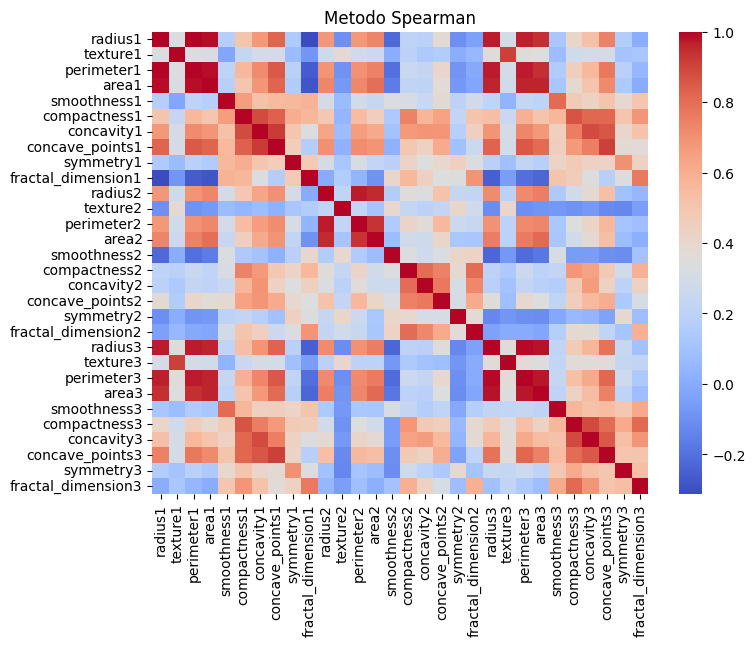

In [29]:
corr_pearson = X.corr(method='pearson')

plt.figure(figsize=(8,6))
plt.title('Metodo Spearman')
sns.heatmap(corr_pearson, cmap='coolwarm')

<Axes: title={'center': 'Metodo Spearman'}>

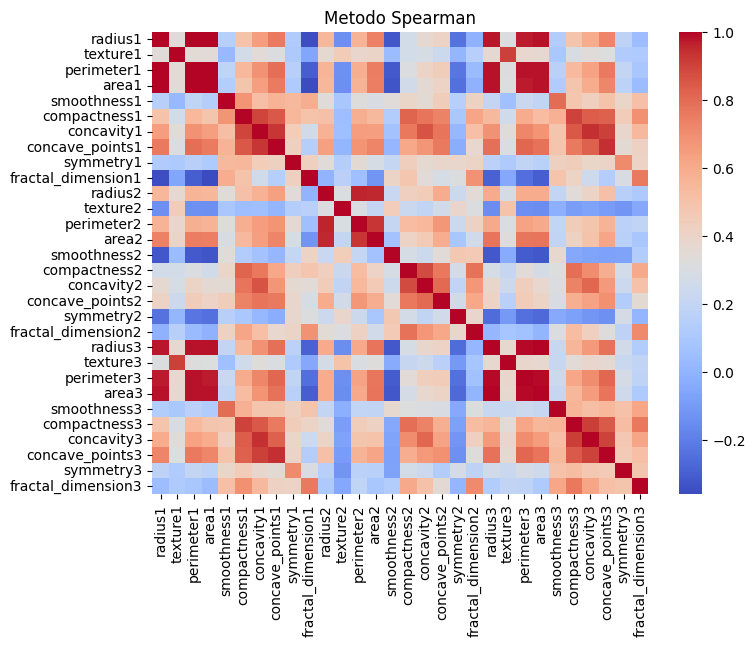

In [30]:
corr_spearman = X.corr(method='spearman')

plt.figure(figsize=(8,6))
plt.title('Metodo Spearman')
sns.heatmap(corr_spearman, cmap='coolwarm')

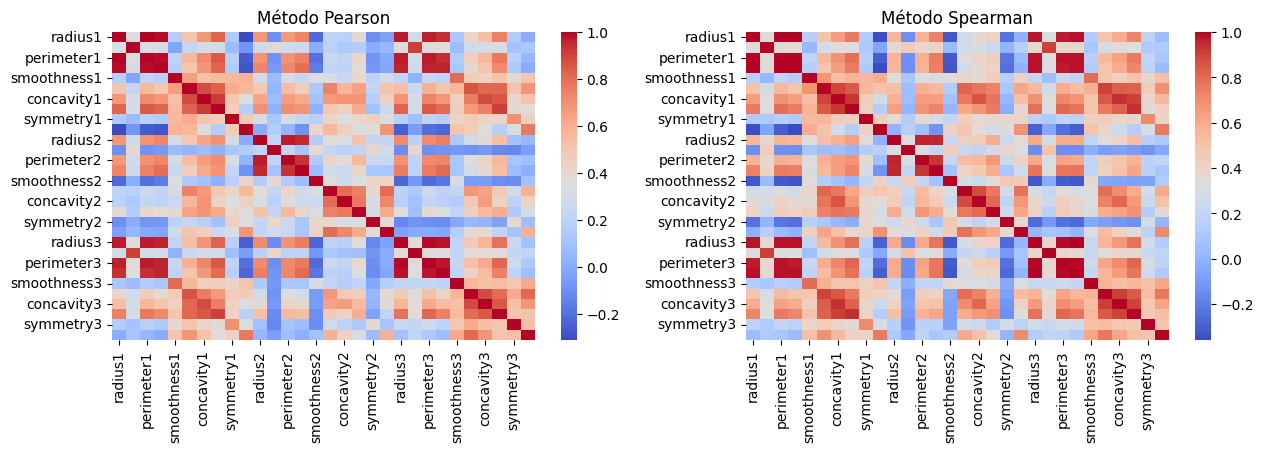

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.heatmap(corr_pearson, ax=axes[0], cmap='coolwarm')
axes[0].set_title('Método Pearson')

sns.heatmap(corr_spearman, ax=axes[1], cmap='coolwarm')
axes[1].set_title('Método Spearman')

plt.show()

In [64]:
for column in columns:
    df_temp = pd.concat([X[column], y], axis=1)
df_temp.head()

,fractal_dimension3,Diagnosis
0,0.11890,M
1,0.08902,M
2,0.08758,M
3,0.17300,M
4,0.07678,M


In [53]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Diagnosis  569 non-null    str  
dtypes: str(1)
memory usage: 4.6 KB


In [58]:
y['Diagnosis'].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

In [ ]:
corr_spearman.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
radius1,1.000000,0.340956,0.997802,0.999602,0.148510,0.497578,0.645728,0.759702,0.120242,-0.349931,...,0.978604,0.314911,0.971555,0.978863,0.125789,0.491357,0.596043,0.727265,0.174698,0.044564
texture1,0.340956,1.000000,0.348142,0.344145,0.024649,0.266499,0.342646,0.306891,0.110130,-0.059303,...,0.366547,0.909218,0.375273,0.368335,0.101401,0.290917,0.339725,0.319235,0.120693,0.116144
perimeter1,0.997802,0.348142,1.000000,0.997068,0.182923,0.543925,0.681958,0.788629,0.150049,-0.304891,...,0.981244,0.323109,0.978980,0.980864,0.156611,0.534565,0.632106,0.757526,0.199007,0.088961
area1,0.999602,0.344145,0.997068,1.000000,0.138053,0.488988,0.642557,0.755165,0.113928,-0.358425,...,0.979258,0.318178,0.971822,0.980264,0.119712,0.485813,0.593736,0.723390,0.170860,0.038758
smoothness1,0.148510,0.024649,0.182923,0.138053,1.000000,0.678806,0.518511,0.565172,0.542228,0.588465,...,0.203453,0.060645,0.226345,0.191735,0.796085,0.481384,0.429107,0.498868,0.393579,0.511457
